# Customer Churn Prediction — Data Loading & Inspection

Loading the Telco Customer Churn dataset and doing an initial structural check
before any cleaning or analysis.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Check the columns and data types
What df.info() tells us

It gives us:

number of rows
column names
how many non-null values each column has
data type of each column

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Check for missing/blank values

In [6]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## Investigate TotalCharges

Let's look specifically for blank strings.

In [7]:
df["TotalCharges"].str.strip().eq("").sum()

np.int64(11)

/*
 Why did df.isnull().sum() say 0?

Because these 11 cells aren't actually stored as NaN.

They're stored as something like: " "
To Pandas, that's a string, not a missing value.So, df.isnull().sum() can't catch them

but when check with df["TotalCharges"].str.strip().eq("").sum()
specifically looked for blank strings, and found 11.
*/

In [8]:
df[df["TotalCharges"].str.strip() == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


But before we clean it...

Let's verify one thing.

We know all 11 have tenure = 0 from looking at the output, but let's make Python confirm it.

In [9]:
df[df["TotalCharges"].str.strip() == ""]["tenure"].value_counts()

,count
tenure,
0,11


## Fix TotalCharges

We want to do two things:

Turn the blank strings into 0.
Convert the entire column from object → numeric.



In [10]:
df["TotalCharges"] = df["TotalCharges"].str.strip().replace("", "0")

## verifying

In [11]:
df[df["TotalCharges"] == "0"]["tenure"]

,tenure
488,0
753,0
936,0
1082,0
1340,0
3331,0
3826,0
4380,0
5218,0
6670,0


In [12]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [13]:
df["TotalCharges"].dtype

dtype('float64')

## check for duplicate rows.

In [14]:
df.duplicated().sum()

np.int64(0)

## What is our churn distribution?

In [15]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


normalize=True
this means: "Instead of giving me the number of customers, give me the proportion of the total."

For example:

No     0.734
Yes    0.266

In [16]:
df["Churn"].value_counts(normalize = True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


So our first business insight is:

About 26.5% of customers in the dataset have churned, while 73.5% have remained.

That's a useful baseline, but it doesn't tell us why customers churn. That's what our EDA will investigate.

seaborn creates the chart, while matplotlib.pyplot lets us control things like:

title
labels
figure size
display

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

### Churn distribution

sns.countplot(data=df, x="Churn")

We're telling Seaborn: Take df, look at the Churn column, count how many times each category occurs, and make a bar for each category.

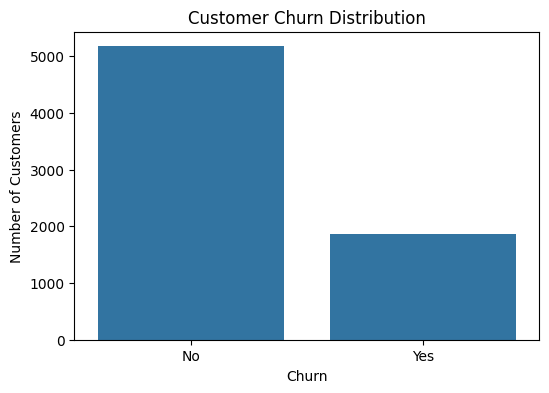

In [18]:
plt.figure(figsize = (6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Does contract type affect churn?

This is a very relevant question for a telecom company:

Are customers on month-to-month contracts more likely to churn than customers on longer contracts?

We'll first calculate the churn rate for each contract type before making a chart. This is important because raw customer counts can be misleading.

creates a cross-tabulation — basically a table showing the relationship between two categorical variables.

normalize="index"

This tells Pandas: Calculate percentages within each contract type.

In [19]:
pd.crosstab(df["Contract"], df["Churn"], normalize = "index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


Visualize churn rate by contract

Use a bar chart because we're comparing three discrete categories.

contract_churn: which gives us the percentage of Yes and No within each contract type.

Then: contract_churn["Yes"]

selects only the churn percentage.

And:  .plot(kind="bar")

turns those percentages into bars.

plt.xticks(rotation=0)

means: Keep the X-axis labels horizontal.

So the chart is answering exactly one question:
What percentage of customers churn within each contract type?

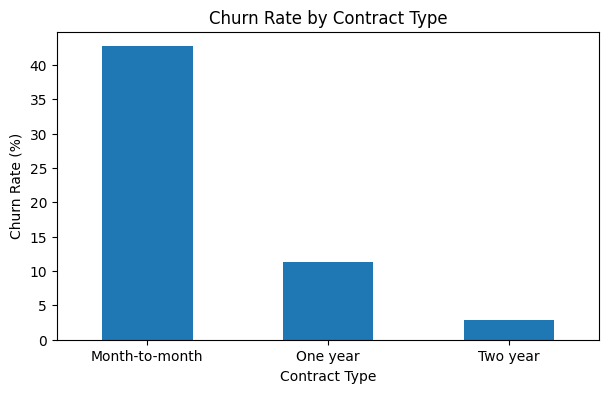

In [20]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize = "index"
)  * 100

contract_churn["Yes"].plot(kind = 'bar', figsize = (7, 4))

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation = 0)

plt.show()

## Our finding

Customers on month-to-month contracts have a substantially higher observed churn rate than customers on one-year and two-year contracts.

## Step 13 — Next question: Does tenure relate to churn?

This is another important telecom question:

Do customers who have been with the company for a longer time churn at a different rate?

tenure is numeric, ranging from 0 to 72 months.

For our first look, we'll create tenure groups rather than making 73 separate categories.

We'll use:

0–12 months
13–24 months
25–48 months
49–72 months

In [21]:
df["tenure"].describe()

,tenure
count,7043.000000
mean,32.371149
std,24.559481
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


## 13.1 Two useful observations

1. Tenure ranges from 0 to 72 months.

So we have customers from brand-new: 0 months

to:

72 months = 6 years

2. Mean and median are different.

Mean   = 32.37 months
Median = 29 months

The mean is higher than the median, suggesting some longer-tenure customers pull the average upward.

But we don't need to draw conclusions about churn from this yet. This only describes the distribution of tenure.

## 13.2 — Create tenure groups

Now we'll create a new feature called: TenureGroup

Why?
Instead of trying to interpret 73 possible values: 0, 1, 2, 3, ..., 72

we can analyze meaningful ranges.
0–12 months
13–24 months
25–48 months
49–72 months

What does bins mean?
We wrote: bins = [0, 12, 24, 48, 72]

Think of these numbers as boundaries, not as the groups themselves.

They create intervals:

0 -------- 12 -------- 24 -------- 48 -------- 72
|           |           |            |          |
     Box 1       Box 2        Box 3       Box 4

There are 5 boundary points, which create 4 intervals.

That's why we have exactly 4 labels:
labels = [
    "0-12 months",
    "13-24 months",
    "25-48 months",
    "49-72 months"
]

Now your main question: where does 12 go?

This is the important part.

By default, pd.cut() creates intervals that are:

(0, 12]
(12, 24]
(24, 48]
(48, 72]

But: 0 is NOT included in (0, 12].

That's where:  include_lowest=True

pd.cut() is a Pandas function used to divide numerical values into ranges (bins).

In [22]:
bins = [0,12,24,48,72]
labels = ["0-12 months", "13-24 months", "25-48 months", "49-72 months"]

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins = bins,
    labels = labels,
    include_lowest = True
)

Verifying


In [23]:
df[["tenure", "TenureGroup"]].head(15)

,tenure,TenureGroup
0,1,0-12 months
1,34,25-48 months
2,2,0-12 months
3,45,25-48 months
4,2,0-12 months
5,8,0-12 months
6,22,13-24 months
7,10,0-12 months
8,28,25-48 months
9,62,49-72 months


In [24]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'TenureGroup'],
      dtype='object')

In [25]:
df["TenureGroup"].value_counts()

,count
TenureGroup,
49-72 months,2239
0-12 months,2186
25-48 months,1594
13-24 months,1024


Check the boundary values specifically

This is the most useful verification for what we just learned about pd.cut():

1. Select rows with specific tenure values
df["tenure"].isin([0, 12, 13, 24, 25, 48, 49, 72]).isin() asks:

"Is the value in this column one of these values?"

So we're looking specifically for customers whose tenure is: 0, 12, 13, 24, 25, 48, 49, 72

It produces something like:

False
False
True
False
...

This is called a Boolean condition.

2. Use that condition to filter the DataFrame df[condition]

So: df[df["tenure"].isin(...)]

means: "Give me only the rows where tenure is one of those boundary values."

3. Select only the two columns we care about
[
    ["tenure", "TenureGroup"]
]

We don't need to see all 21 columns.

We only want:

tenure       TenureGroup
------       -----------
0            0-12 months
12           0-12 months
13           13-24 months
...

4. Sort by tenure
.sort_values("tenure")

In [26]:
df[df["tenure"].isin([0,12,13,24,25,48,49,72])][["tenure", "TenureGroup"]].sort_values("tenure")


,tenure,TenureGroup
6754,0,0-12 months
3826,0,0-12 months
3331,0,0-12 months
488,0,0-12 months
6670,0,0-12 months
...,...,...
167,72,49-72 months
140,72,49-72 months
7039,72,49-72 months
7022,72,49-72 months


## 13.3 — Churn Rate by Tenure Group
Why are we doing this?

We already know: Overall churn is about 26.5%
Contract type has a strong difference in observed churn.
We also saw that customers have very different lengths of time with the company.

Now we want to answer: "Does observed churn differ depending on how long a customer has been with the company?"

This is much more useful than simply looking at the average tenure.

crosstab() creates a cross-tabulation, basically a table showing the relationship between two categorical variables.

Here:

pd.crosstab(
    df["TenureGroup"],
    df["Churn"]
)

means: "Create a table showing Churn values for each TenureGroup."

Without normalize, we'd get counts. Something conceptually like:

Churn          No     Yes
TenureGroup
0-12           1200   1000
13-24          1000    300
25-48          1500    250
49-72          1400    300

But counts aren't ideal because the groups may contain different numbers of customers.

normalize="index"

This is the important part:

normalize="index"

It tells Pandas:

"For each TenureGroup, convert the counts into percentages."

In [27]:
tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize = "index"
) * 100

In [28]:
tenure_churn

Churn,No,Yes
TenureGroup,,
0-12 months,52.561757,47.438243
13-24 months,71.289062,28.710938
25-48 months,79.611041,20.388959
49-72 months,90.486824,9.513176


## Create the visualization

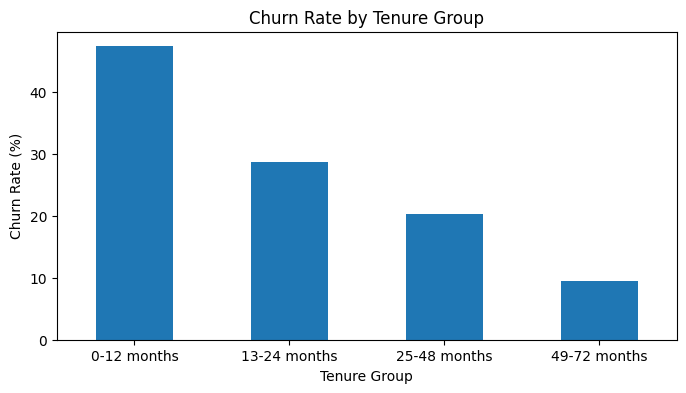

In [29]:
tenure_churn["Yes"].plot(kind = "bar", figsize = (8,4))

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation = 0)  # Keep the X-axis labels at 0° rotation — completely horizontal.
plt.show()

## Monthly Charges vs Churn
Why do we want this?

We already looked at how long customers stay.
Now we want to investigate:

Do customers with higher monthly charges have different observed churn rates?

## Step 1 — Compare average monthly charges


In [30]:
df.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
No,61.265124
Yes,74.441332


The middle line is the median.

The box represents the middle 50% of observations.

The lines extending from the box show the broader range of typical values, while individual points beyond them can represent potential outliers.

So customers who churned had a higher median monthly charge than customers who stayed.

The middle 50% of churned customers also appears shifted toward higher monthly charges.

Customers who churned had higher typical monthly charges than customers who stayed, indicating an association between higher monthly charges and observed churn in this dataset.

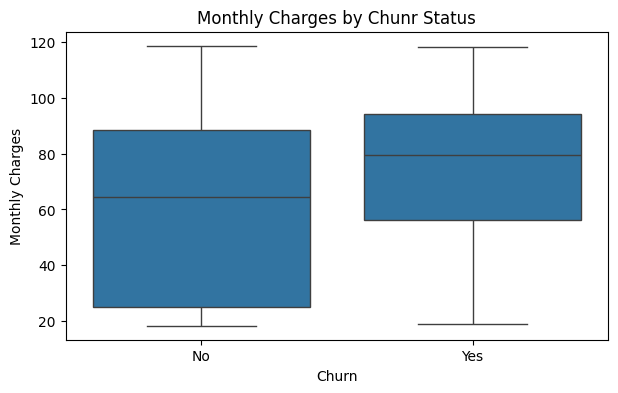

In [32]:
plt.figure(figsize = (7, 4))

sns.boxplot(
    data = df,
    x = "Churn",
    y = "MonthlyCharges"
)

plt.title("Monthly Charges by Chunr Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

## Internet Service vs Churn

This is another important categorical feature because the dataset has:

DSL
Fiber optic
No

We want to answer:

Does observed churn rate differ across Internet Service types?

In [33]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn


Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


What does this tell us?

There is a large difference in observed churn rates across Internet Service categories.

The most noticeable pattern is that Fiber optic customers have the highest observed churn rate in this dataset, while customers without internet service have the lowest.

Customers with fiber-optic internet service show a substantially higher observed churn rate than customers with DSL or no internet service.

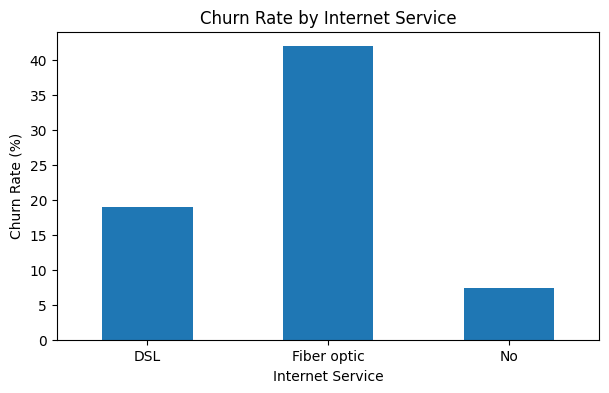

In [34]:
internet_churn["Yes"].plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

## Payment Method vs Churn
This is another categorical variable:

PaymentMethod

It contains different payment methods such as electronic check, mailed check, bank transfer, and credit card.

We want to know:

Does observed churn rate differ by payment method?

In [35]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


### What stands out?

Customers using electronic check have a substantially higher observed churn rate than the other payment-method groups.

So our project finding can be:

Electronic-check customers show a substantially higher observed churn rate than customers using other payment methods in this dataset.

Again, we should not say electronic checks cause churn. There may be other customer characteristics associated with both payment method and churn.

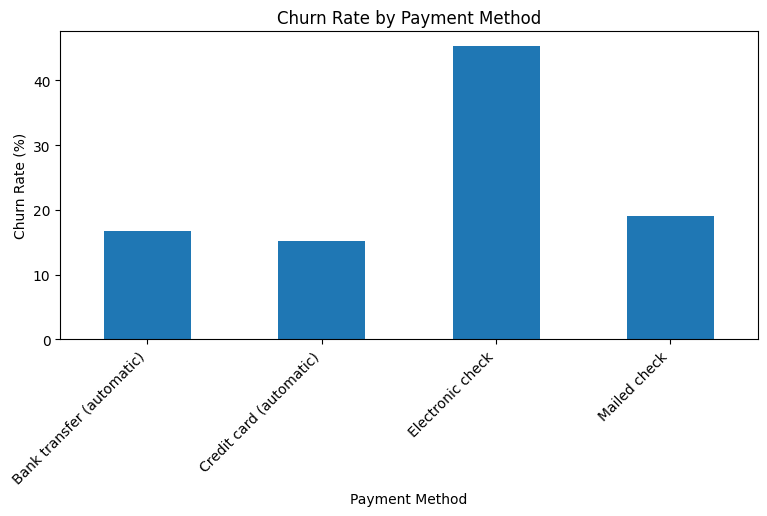

In [36]:
payment_churn["Yes"].plot(
    kind="bar",
    figsize=(9, 4)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

## Service Features vs Churn

Now I want to examine several service-related columns together.

These are:

OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Why these?

They're customer services/features, and they could reveal whether customers who have or don't have particular services show different observed churn rates

In [40]:
service_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

service_churn = {}

for col in service_cols:
    service_churn[col] = pd.crosstab(
        df[col],
        df["Churn"],
        normalize="index"
    )["Yes"] * 100

### 1. What did we calculate?

For each service, we calculated:Churn rate for each category of that service.

For example, for OnlineSecurity:

OnlineSecurity
No                  41.77%
No internet service  7.40%
Yes                 14.61%

This means:

Among customers without Online Security, about 41.8% churned.
Among customers with Online Security, about 14.6% churned.
Customers with no internet service have about 7.4% churn.

That's a very large difference.

In [42]:
#  service_churn

 service_churn_df = pd.DataFrame(service_churn)

service_churn_df

,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
No,41.766724,39.928756,39.127625,41.635474,33.523132,33.680431
No internet service,7.404980,7.404980,7.404980,7.404980,7.404980,7.404980
Yes,14.611194,21.531494,22.502064,15.166341,30.070188,29.941435


### one comparison chart
A grouped chart lets us visually compare the churn rates for customers who have vs don't have each service.

However, we don't need the "No internet service" category for this particular comparison because, as we just discovered, it's essentially the same group repeated across the internet-dependent service columns

### What stands out?

The largest differences are for:

Online Security
Tech Support
Online Backup
Device Protection

For example:

Online Security:
No  → 41.8%
Yes → 14.6%

while:

Streaming TV:
No  → 33.5%
Yes → 30.1%

So the difference is much smaller for the streaming services.

Our finding

We can document:

Customers without services such as online security, online backup, device protection, and tech support show substantially higher observed churn rates than customers who have these services. The difference is smaller for streaming services.

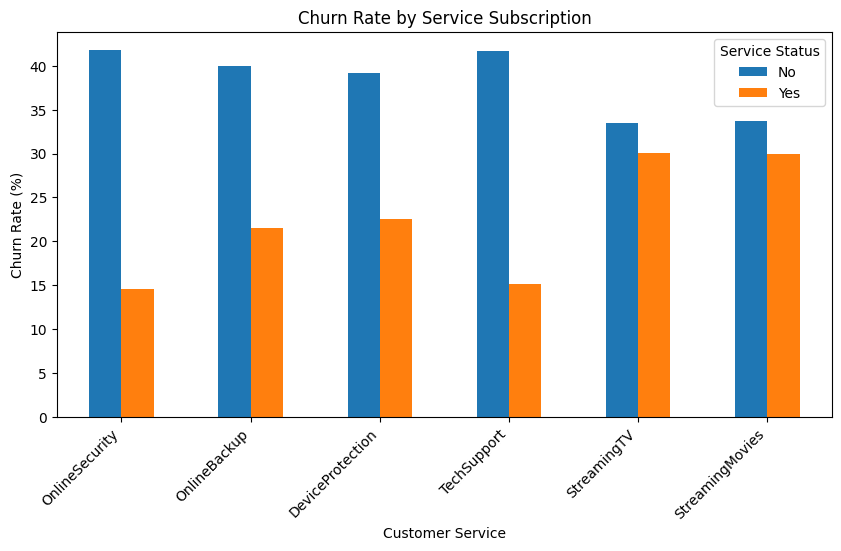

In [44]:
service_churn_df.loc[['No', 'Yes']].T.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Churn Rate by Service Subscription")
plt.xlabel("Customer Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Service Status")
plt.show()

# One final Day-1 task: consolidate our findings

## Key EDA Findings

1. **Overall churn:** Approximately 26.5% of customers in the dataset have churned, while 73.5% have stayed.

2. **Contract type:** Month-to-month customers show a substantially higher observed churn rate than customers on one-year and two-year contracts.

3. **Tenure:** Customers with shorter tenure show higher observed churn rates than customers with longer tenure.

4. **Monthly charges:** Customers who churned have higher typical monthly charges than customers who stayed.

5. **Internet service:** Fiber-optic customers show a substantially higher observed churn rate than DSL and customers without internet service.

6. **Payment method:** Customers using electronic checks show a substantially higher observed churn rate than customers using other payment methods.

7. **Additional services:** Customers without online security, online backup, device protection, and technical support show substantially higher observed churn rates than customers with these services. The difference is smaller for streaming services.

### Important interpretation note

These findings describe associations observed in the dataset. They do not establish that any individual feature causes customer churn.